# Diferential Expression (DE) analysis K8B_S13553

Code from: https://git.lumc.nl/hem/FL_10X_2/-/blob/master/410_S144_case/S144_analysis.Rmd

- title: "Focus on S144 NliG"
- author:
  - name: C.A.M. van Bergen
  - affiliation: Leiden University Medical Center

In [6]:
# load packages and user-defined functions
options(warn=-1)
suppressPackageStartupMessages( library( DESeq2 ) )
suppressPackageStartupMessages( library( BiocParallel ) )
library(tidyverse)
library(data.table)
library("AnnotationDbi")
library("org.Hs.eg.db")
library(pathview)
library(gage)
library(gageData)
data(kegg.sets.hs)
data(sigmet.idx.hs)
kegg.sets.hs = kegg.sets.hs[sigmet.idx.hs]
library(scran)
library('glmGamPoi')

Loading required package: SingleCellExperiment

Loading required package: scuttle



In [7]:
suppressMessages(source("code/functions.R"))

In [3]:
# #Load input data (raw data, all cells)

# df_seq <- Sys.glob("input/output_shm_20220819/*/consensus/*/*.csv") %>%
#   purrr::map_dfr(function(x) {
#     readr::read_csv(x, col_types = "cciccici", progress = FALSE) %>%
#       dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x)) %>%
#       filter(ref_vdj_coverage == '1.0')
#   })

In [8]:
trully_negative <- read.csv("output/trully_negative_cells.csv")

In [9]:
str(trully_negative)

'data.frame':	3417 obs. of  2 variables:
 $ source: chr  "K4B" "K4B" "K4B" "K4B" ...
 $ cell  : chr  "AAACCTGTCACGAAGG" "AAACGGGAGTGGCACA" "AAACGGGGTCTAGCGC" "AAAGCAAGTACTTAGC" ...


In [10]:
# seurat object
FL.integrated <- readRDS("output/K45678_integrated.rds")

In [11]:
#barcodes of cells group 2
cells1 <- read.csv("output/df_summary_K45678_v5.csv") %>% mutate(experiment=str_extract(subject, "^.{2}")) %>%
          filter(subject %like% "K8B") %>% mutate(cell_seurat=case_when(experiment == "K8" ~ paste0(cell,"-1_5"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>%
        pull(cell_seurat) %>% unique()

#barcodes of cells group 1
# cells2 <- df_seq %>% filter(cell %in% trully_negative$cell) %>% mutate(experiment=str_extract(subject, "^.{2}")) %>% mutate(cell_seurat=case_when(experiment == "K4" ~ paste0(cell,"-1_1"),
#                                                                                              experiment == "K5" ~ paste0(cell,"-1_2"),
#                                                                                              experiment == "K6" ~ paste0(cell,"-1_3"),
#                                                                                              experiment == "K7" ~ paste0(cell,"-1_4"),
#                                                                                              experiment == "K8" ~ paste0(cell,"-1_5"),
#                                                                                              TRUE ~ "NA"
#                                                                                                  )) %>% filter(!cell_seurat %in% cells1) %>%
#            pull(cell_seurat) %>% unique() %>% sample(2000)

cells2 <- trully_negative %>% mutate(cell_seurat=case_when(source == "K4B" ~ paste0(cell,"-1_1"),
                                                                                             source == "K5B" ~ paste0(cell,"-1_2"),
                                                                                             source == "K6B" ~ paste0(cell,"-1_3"),
                                                                                             source == "K7B" ~ paste0(cell,"-1_4"),
                                                                                             source == "K8B" ~ paste0(cell,"-1_5"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>% 
           pull(cell_seurat) %>% unique() %>% sample(300)

In [12]:
cells1 %>% str()
cells2 %>% str()

 chr [1:77] "CGAGAAGAGGCTATCT-1_5" "GACGGCTGTTCTGAAC-1_5" ...
 chr [1:300] "GACGGCTCAGTAGAGC-1_4" "CCTATTATCTCCGGTT-1_1" ...


**The package DESeq2 provides methods to test for differential expression by use of negative binomial generalized linear models; the estimates of dispersion and logarithmic fold changes incorporate data-driven prior distributions.**
- **Why un-normalized counts?**
As input, the DESeq2 package expects count data as obtained, e.g., from RNA-seq or another high-throughput sequencing experiment, in the form of a matrix of integer values. The value in the i-th row and the j-th column of the matrix tells how many reads can be assigned to gene i in sample j. Analogously, for other types of assays, the rows of the matrix might correspond e.g. to binding regions (with ChIP-Seq) or peptide sequences (with quantitative mass spectrometry). We will list method for obtaining count matrices in sections below.
The values in the matrix should be un-normalized counts or estimated counts of sequencing reads (for single-end RNA-seq) or fragments (for paired-end RNA-seq). The RNA-seq workflow describes multiple techniques for preparing such count matrices. It is important to provide count matrices as input for DESeq2’s statistical model (Love, Huber, and Anders 2014) to hold, as only the count values allow assessing the measurement precision correctly. The DESeq2 model internally corrects for library size, so transformed or normalized values such as counts scaled by library size should not be used as input.

In [13]:
DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( group = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( group = 1 ) ) %>%
      column_to_rownames( var = "." ) %>% 
      mutate( group = factor( group, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
      rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
      filter( !geneName %like% "^RPL",
              !geneName %like% "^RPS",
              !geneName %like% "^IG[HKL][VMCG]",
              !geneName %like% "^MT-" ) %>% 
      column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = round(cts),
                              colData   = d,
                              design    = ~ group )
    
    # set test and reference
    dds$cluster <-
      relevel( dds$group, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi",
             parallel = FALSE, 
             test="LRT",
             reduced = ~ 1,
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )
    
    
    # collect results, specify coefficient
    res <-
      results( dds )
    
    # extract data from res, all genes
    DEgenes <- bind_cols( res@rownames,
                          res@listData$log2FoldChange,
                          res@listData$lfcSE,
                          res@listData$pval,
                          res@listData$padj ) %>%
      `colnames<-`( c( "rowname", "log2FoldChange", "lfcSE", "pval", "padj" ) )
    
    return( DEgenes)
  }

- if it dosen't work run cells again 

In [14]:
DE_scSHM <- DEgenes(sObject, cells1, cells2) 

converting counts to integer mode

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

using 'glmGamPoi' as fitType. If used in published research, please cite:
    Ahlmann-Eltze, C., Huber, W. (2020) glmGamPoi: Fitting Gamma-Poisson
    Generalized Linear Models on Single Cell Count Data. Bioinformatics.
    https://doi.org/10.1093/bioinformatics/btaa1009

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Fit reduced model

Calculate quasi likelihood ratio

Prepare results

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`


In [15]:
# volcano plot
# input is table with DE genes
VolcanoPlot <-
  function( d ){
    ggplot( d %>%
              filter( !is.na( padj ) ),
            aes( x = log2FoldChange, y = -log10( padj ) ) ) +
      geom_point( size = 0.5) +
      geom_hline( yintercept = -log10( 0.05), linetype="dashed",  color = "grey" ) +
      geom_vline( xintercept = -0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      geom_vline( xintercept = 0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      ggrepel::geom_text_repel(
        data =  bind_rows( d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( log2FoldChange )  %>%
                             dplyr::slice( 1:16 ),
                           d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( desc( log2FoldChange ) ) %>%
                             dplyr::slice( 1:16 ),
                           d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( padj ) %>%
                             dplyr::slice( 1:16 ) ) %>%
          # distinct on 2 variables to keep genes
          distinct( rowname, .keep_all = TRUE) %>%
          filter( !is.na( log2FoldChange ),
                  log2FoldChange < -0.5 | log2FoldChange > 0.5),
        aes( label = rowname ), color = "red", size = 3 ) }

VolcanoPlotFixedFrame <-
  function( d ){
    # remove padj = NA
    d <-
      filter( d, !is.na( padj ) )
    # maximize coordinates for better comparison
    if( min( d$log2FoldChange ) < -2.5 ){
      d[ which( d$log2FoldChange < - 2.5 ), "log2FoldChange" ] <-
        - 1 }
    if( max( d$log2FoldChange ) > 2.5 ){
      d[ which( d$log2FoldChange > 2.5 ), "log2FoldChange" ] <-
        1 }
    if( min( d$padj ) < 1e-80 ){
      d[ which( d$padj < 1e-80 ), "padj" ] <-
        1e-80 }
    
    ggplot( d,
            aes( x = log2FoldChange, y = -log10( padj ) ) ) +
      geom_point( size = 0.5) +
      xlim( c( -2.5, 2.5 ) ) +
      ylim( c( 1, -log10( 1e-80 ) ) ) +
      geom_point( data = d %>% 
                    filter( log2FoldChange > -.5 & log2FoldChange < .5 ),
                  aes(  x = log2FoldChange, y = -log10( padj ) ), size = 0.5, color = "grey" ) +
      geom_hline( yintercept = -log10( 0.05), linetype="dashed",  color = "grey" ) +
      geom_vline( xintercept = -0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      geom_vline( xintercept = 0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      ggrepel::geom_text_repel(
        data =  bind_rows( d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( log2FoldChange )  %>%
                             dplyr::slice( 1:25 ),
                           d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( desc( log2FoldChange ) ) %>%
                             dplyr::slice( 1:25 ),
                           d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( padj ) %>%
                             dplyr::slice( 1:25 ) ) %>%
          # distinct on 2 variables to keep genes
          distinct( rowname, .keep_all = TRUE) %>%
          filter( !is.na( log2FoldChange ),
                  log2FoldChange < -0.5 | log2FoldChange > 0.5),
        aes( label = rowname ), color = "red", size = 2.5, segment.size = 0.2 )
  }

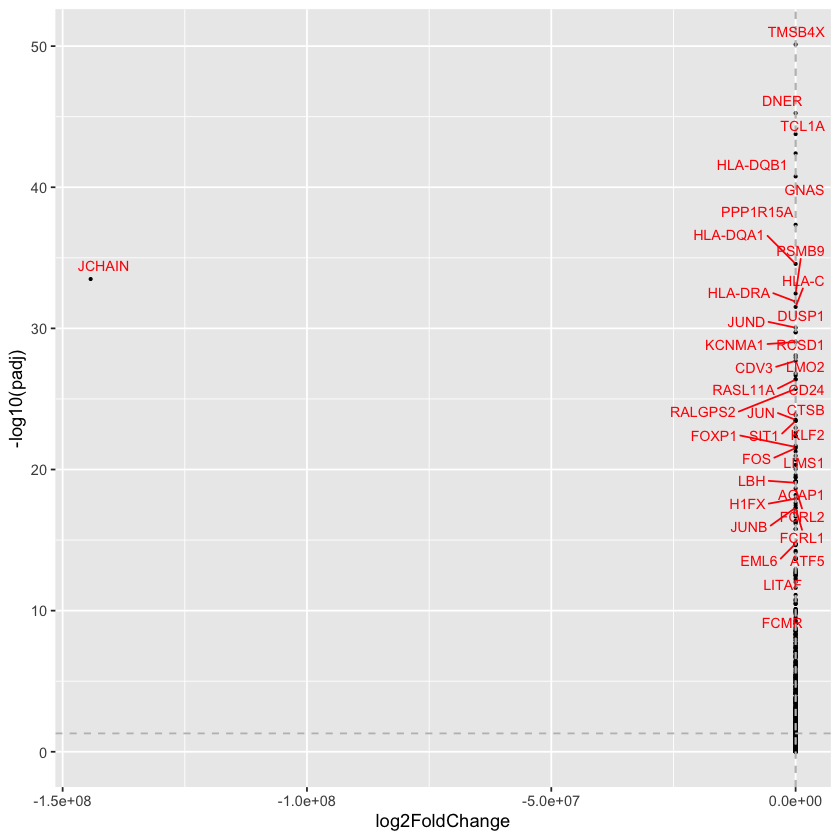

In [16]:
td <- VolcanoPlot(DE_scSHM)
td

In [17]:
fig_save(td , filename = ("figs/volcano_plot_S13553"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

If within a row, all samples have zero counts, the baseMean column will be zero, and the log2 fold change estimates, p value and adjusted p value will all be set to NA.
If a row contains a sample with an extreme count outlier then the p value and adjusted p value will be set to NA. These outlier counts are detected by Cook’s distance. Customization of this outlier filtering and description of functionality for replacement of outlier counts and refitting is described below
If a row is filtered by automatic independent filtering, for having a low mean normalized count, then only the adjusted p value will be set to NA. Description and customization of independent filtering is described below

# Pathway analysis

### Convert genes names to Entrez Gene

In [19]:
DE_scSHM$entrez = mapIds(org.Hs.eg.db,
                     keys=DE_scSHM$rowname, 
                     column="ENTREZID",
                     keytype="SYMBOL",
                     multiVals="first")
DE_scSHM$name =   mapIds(org.Hs.eg.db,
                     keys=DE_scSHM$rowname, 
                     column="GENENAME",
                     keytype="SYMBOL",
                     multiVals="first")

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



In [20]:
DE_scSHM %>% filter(padj < 0.05) %>% str()

tibble [465 × 7] (S3: tbl_df/tbl/data.frame)
 $ rowname       : chr [1:465] "PARK7" "ENO1" "CAPZB" "CDC42" ...
 $ log2FoldChange: num [1:465] -0.837 -1.445 -0.701 -0.669 -2.485 ...
 $ lfcSE         : logi [1:465] NA NA NA NA NA NA ...
 $ pval          : num [1:465] 7.59e-06 4.06e-10 4.92e-05 1.21e-03 3.54e-11 ...
 $ padj          : num [1:465] 3.19e-05 3.10e-09 1.83e-04 3.36e-03 3.00e-10 ...
 $ entrez        : Named chr [1:465] "11315" "2023" "832" "998" ...
  ..- attr(*, "names")= chr [1:465] "PARK7" "ENO1" "CAPZB" "CDC42" ...
 $ name          : Named chr [1:465] "Parkinsonism associated deglycase" "enolase 1" "capping actin protein of muscle Z-line subunit beta" "cell division cycle 42" ...
  ..- attr(*, "names")= chr [1:465] "PARK7" "ENO1" "CAPZB" "CDC42" ...


## Generally Applicable Gene-set Enrichment for Pathway Analysis

In [61]:
# pathways not related with B cells
unvaluable_pathway <- c("hsa04650 Natural killer cell mediated cytotoxicity","hsa04380 Osteoclast differentiation",
                        "hsa04966 Collecting duct acid secretion","hsa04971 Gastric acid secretion","hsa04914 Progesterone-mediated oocyte maturation",
                        "hsa04720 Long-term potentiation","hsa04916 Melanogenesis", "hsa04260 Cardiac muscle contraction")

In [62]:
#remove those pathways from the list genes
kegg.sets.hs_filter <- discard(kegg.sets.hs, (names(kegg.sets.hs) %in% unvaluable_pathway ))

In [63]:
#DE_scSHM_filter <- DE_scSHM %>% filter(padj < 0.05)

In [67]:
foldchanges = DE_scSHM$log2FoldChange
names(foldchanges) = DE_scSHM$entrez
head(foldchanges)

11315       2023        832     440574       1650      50809 
-0.8370074 -1.4447366 -0.7013937  0.1110449  0.1778631 -0.0799102

In [68]:
# Get the results
keggres = gage(foldchanges, gsets=kegg.sets.hs_filter, same.dir=TRUE)

# Look at both up (greater), down (less), and statatistics.
lapply(keggres, head,10)

,p.geomean,stat.mean,p.val,q.val,set.size,exp1
hsa00190 Oxidative phosphorylation,0.3958427,0.2652290,0.3958427,0.4597131,65,0.3958427
hsa03040 Spliceosome,0.4122250,0.2231223,0.4122250,0.4597131,46,0.4122250
hsa04145 Phagosome,0.4234224,0.1946249,0.4234224,0.4597131,35,0.4234224
hsa04141 Protein processing in endoplasmic reticulum,0.4291292,0.1801877,0.4291292,0.4597131,30,0.4291292
hsa04612 Antigen processing and presentation,0.4315515,0.1740778,0.4315515,0.4597131,28,0.4315515
hsa03013 RNA transport,0.4327968,0.1709410,0.4327968,0.4597131,27,0.4327968
hsa04810 Regulation of actin cytoskeleton,0.4353624,0.1644875,0.4353624,0.4597131,25,0.4353624
hsa04722 Neurotrophin signaling pathway,0.4422926,0.1471225,0.4422926,0.4597131,20,0.4422926
hsa04514 Cell adhesion molecules (CAMs),0.4437846,0.1433979,0.4437846,0.4597131,19,0.4437846
hsa04144 Endocytosis,0.4437849,0.1433969,0.4437849,0.4597131,19,0.4437849


In [ ]:
# Get the pathways
keggrespathways = data.frame(id=rownames(keggres$greater), keggres$greater) %>% 
  tbl_df() %>% 
  filter(row_number()<=5) %>% 
  .$id %>% 
  as.character()
keggrespathways

In [ ]:
# Get the IDs.
keggresids = substr(keggrespathways, start=1, stop=8)
keggresids

In [ ]:
# # Define plotting function for applying later
# plot_pathway = function(pid) pathview(gene.data=foldchanges, pathway.id=pid, species="hsa", new.signature=FALSE)

# # plot multiple pathways (plots saved to disk and returns a throwaway list object)
# tmp = sapply(keggresids, function(pid) pathview(gene.data=foldchanges, pathway.id=pid, species="hsa")) #kegg.native = F, same.layer = F

In [ ]:
# write.csv(DE_scSHM, "output/DE_scSHM.csv")

# test 

In [ ]:
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@data  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
#      dplyr::select( rownames( cell1) ) %>%
      rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
      filter(geneName %like% "JUND" ) 

In [ ]:
ctsd <- ctsd %>% as.data.frame() 

In [ ]:
head(ctsd)

In [ ]:
cells1

In [ ]:
rownames(ctsd)

In [ ]:
head(cells1)

In [ ]:
head(ctsd)

In [ ]:
DF.new <-  ctsd[row.names(ctsd) %in% cells1,]

In [ ]:
head(DF.new)

In [ ]:
colnames(DF.new) <- c("expression")

In [ ]:
DF.new2 <- DF.new %>% rownames_to_column( var = "cell" ) %>% mutate(gene="JUND",expression = as.numeric(expression)) 

In [ ]:
head(DF.new2)

In [ ]:
# Basic violin plot
ggplot(DF.new2, aes(x=gene, y=expression)) + 
  geom_violin(trim=FALSE, fill="gray")+
  labs(title="Plot of Expression gene x",x="Gene)", y = "Expression")+
  geom_boxplot(width=0.3)+
  theme_classic()
# Change color by groups
dp <- ggplot(DF.new2, aes(x=gene, y=expression)) + 
  geom_violin(trim=FALSE)+
  geom_boxplot(width=0.1, fill="white")+
  labs(title="Plot of Expression gene x",x="Gene)", y = "Expression")
dp + theme_classic() +
geom_dotplot(binaxis='y', stackdir='center', dotsize=0.1)

In [ ]:
# Basic violin plot
ggplot(DF.new2, aes(x=gene, y=expression)) + 
  geom_violin(trim=FALSE, fill="gray")+
  labs(title="Plot of Expression gene x",x="Gene)", y = "Expression")+
  geom_boxplot(width=0.3)+
  theme_classic()
# Change color by groups
dp <- ggplot(DF.new2, aes(x=gene, y=expression)) + 
  geom_violin(trim=FALSE)+
  geom_boxplot(width=0.3, fill="white")+
  labs(title="Plot of Expression gene x",x="Gene)", y = "Expression")
dp + theme_classic() +
geom_dotplot(binaxis='y', stackdir='center', dotsize=0.5)